# Selected XGBoost predictive robustness

This notebook evaluates whether the selected market-only XGBoost specification remains informative for prespecified alternative downside-risk definitions and horizons. Model features and hyperparameters remain frozen. Each alternative-target model is fitted on the chronologically valid training and validation observations and evaluated once on its held-out test observations.

In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

project_root = Path.cwd().resolve()
while not (project_root / 'src').is_dir():
    if project_root == project_root.parent:
        raise RuntimeError('Project root could not be located.')
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.modeling.robustness import _target_samples
from src.modeling.tabular_selection import (
    PREDICTION, TARGET, feature_names, fit_preprocessor,
    transform_features,
)
from src.utils.configuration import get_paths_config, get_project_config
from src.visualization.style import (
    COLOR_PALETTE, SINGLE_PANEL_SIZE, apply_matplotlib_layout,
    set_matplotlib_style,
)

paths = get_paths_config()
project = get_project_config()
modeling_tables = paths.tables / 'modeling'
set_matplotlib_style()
target_labels = {
    'future_max_drawdown_63d': '63-day maximum drawdown',
    'future_downside_volatility_63d': '63-day downside volatility',
    'future_worst_five_day_loss_63d': 'Worst five-day loss',
    'future_max_drawdown_21d': '21-day maximum drawdown',
    'future_max_drawdown_126d': '126-day maximum drawdown',
}
feature_labels = {
    'market_cap_usd': 'Log market capitalization',
    'return_21d': 'Return (21 days)',
    'momentum_252_21d': 'Momentum (252--21 days)',
    'downside_volatility_63d': 'Downside volatility (63 days)',
    'market_beta_252d': 'Market beta (252 days)',
    'maximum_drawdown_252d': 'Maximum drawdown (252 days)',
    'negative_return_share_63d': 'Negative-return share (63 days)',
}

## Refit the frozen specification for alternative targets

In [2]:
samples = _target_samples(
    paths.processed / 'modeling' / 'modeling_sample.parquet',
    paths.processed / 'modeling' / 'robustness_targets.parquet',
    feature_names('market'),
)
xgboost_parameters = {
    'n_estimators': 90, 'max_depth': 3, 'min_child_weight': 1,
    'learning_rate': 0.10, 'subsample': 0.80, 'colsample_bytree': 0.80,
}
performance_rows = []
prediction_frames = []
decile_frames = []

for target_name, sample in samples.items():
    fitting = sample.loc[sample['sample_split'].isin(['train', 'validation'])].copy()
    test = sample.loc[sample['sample_split'].eq('test')].copy()
    preprocessing = fit_preprocessor(fitting, 'market', standardize=False)
    fitting_x = transform_features(fitting, preprocessing)
    test_x = transform_features(test, preprocessing)
    model = XGBRegressor(
        **xgboost_parameters, objective='reg:squarederror', eval_metric='mae',
        random_state=project.seed, n_jobs=4, tree_method='hist', verbosity=0,
    ).fit(fitting_x, fitting['target_value'])
    prediction = np.maximum(model.predict(test_x), 0)
    if target_name != 'future_downside_volatility_63d':
        prediction = np.minimum(prediction, 1)
    output = test[['report_period', 'information_date', 'permno', 'target_value']].copy()
    output['target'] = target_name
    output['prediction'] = prediction
    output['score'] = output.groupby('report_period')['prediction'].rank(
        method='average', pct=True
    )
    output['decile'] = np.ceil(10 * output['score']).astype(int).clip(1, 10)
    quarterly_spearman = output.groupby('report_period').apply(
        lambda group: group['target_value'].corr(group['prediction'], method='spearman'),
        include_groups=False,
    )
    deciles = output.groupby(['report_period', 'decile'], as_index=False).agg(
        observations=('permno', 'size'), mean_actual=('target_value', 'mean'),
        mean_prediction=('prediction', 'mean'),
    )
    deciles['target'] = target_name
    mean_deciles = deciles.groupby('decile', as_index=False)['mean_actual'].mean()
    performance_rows.append({
        'target': target_name, 'test_observations': len(output),
        'test_quarters': output['report_period'].nunique(),
        'mae': mean_absolute_error(output['target_value'], prediction),
        'rmse': mean_squared_error(output['target_value'], prediction) ** 0.5,
        'r2': r2_score(output['target_value'], prediction),
        'mean_quarterly_spearman': quarterly_spearman.mean(),
        'decile_1_mean': mean_deciles.loc[mean_deciles['decile'].eq(1), 'mean_actual'].item(),
        'decile_10_mean': mean_deciles.loc[mean_deciles['decile'].eq(10), 'mean_actual'].item(),
    })
    prediction_frames.append(output)
    decile_frames.append(deciles)
    joblib.dump(
        {'model': model, 'preprocessing': preprocessing, 'target': target_name,
         'feature_group': 'market', 'hyperparameters': xgboost_parameters},
        paths.models / f'robustness_xgboost_{target_name}.joblib',
    )

alternative_performance = pd.DataFrame(performance_rows)
alternative_predictions = pd.concat(prediction_frames, ignore_index=True)
alternative_deciles = pd.concat(decile_frames, ignore_index=True)

## Add the primary target as a reference

In [3]:
primary = pd.read_parquet(
    modeling_tables / 'final_models_test_predictions.parquet'
).loc[lambda frame: frame['model'].eq('XGBoost')].copy()
primary['target'] = 'future_max_drawdown_63d'
primary['target_value'] = primary[TARGET]
primary['prediction'] = primary[PREDICTION]
primary['score'] = primary.groupby('report_period')['prediction'].rank(
    method='average', pct=True
)
primary['decile'] = np.ceil(10 * primary['score']).astype(int).clip(1, 10)
primary_quarterly_spearman = primary.groupby('report_period').apply(
    lambda group: group['target_value'].corr(group['prediction'], method='spearman'),
    include_groups=False,
)
primary_deciles = primary.groupby(['report_period', 'decile'], as_index=False).agg(
    observations=('permno', 'size'), mean_actual=('target_value', 'mean'),
    mean_prediction=('prediction', 'mean'),
)
primary_deciles['target'] = 'future_max_drawdown_63d'
primary_mean_deciles = primary_deciles.groupby('decile', as_index=False)['mean_actual'].mean()
primary_row = pd.DataFrame([{
    'target': 'future_max_drawdown_63d', 'test_observations': len(primary),
    'test_quarters': primary['report_period'].nunique(),
    'mae': mean_absolute_error(primary['target_value'], primary['prediction']),
    'rmse': mean_squared_error(primary['target_value'], primary['prediction']) ** 0.5,
    'r2': r2_score(primary['target_value'], primary['prediction']),
    'mean_quarterly_spearman': primary_quarterly_spearman.mean(),
    'decile_1_mean': primary_mean_deciles.loc[primary_mean_deciles['decile'].eq(1), 'mean_actual'].item(),
    'decile_10_mean': primary_mean_deciles.loc[primary_mean_deciles['decile'].eq(10), 'mean_actual'].item(),
}])
robustness_performance = pd.concat(
    [primary_row, alternative_performance], ignore_index=True
)
robustness_performance['top_bottom_spread'] = (
    robustness_performance['decile_10_mean']
    - robustness_performance['decile_1_mean']
)
robustness_deciles = pd.concat([primary_deciles, alternative_deciles], ignore_index=True)
robustness_predictions = pd.concat([
    primary[['report_period', 'information_date', 'permno', 'target_value',
             'target', 'prediction', 'score', 'decile']],
    alternative_predictions,
], ignore_index=True)

## Robustness results

In [4]:
robustness_performance.to_csv(
    modeling_tables / 'selected_xgboost_prediction_robustness.csv', index=False
)
robustness_predictions.to_parquet(
    modeling_tables / 'selected_xgboost_robustness_predictions.parquet', index=False
)
robustness_deciles.to_csv(
    modeling_tables / 'selected_xgboost_robustness_deciles.csv', index=False
)
report_table = robustness_performance.copy()
report_table['target'] = report_table['target'].map(target_labels)
report_table = report_table[[
    'target', 'test_observations', 'test_quarters', 'mae', 'rmse', 'r2',
    'mean_quarterly_spearman', 'top_bottom_spread',
]]
report_table.to_csv(
    modeling_tables / 'selected_xgboost_prediction_robustness_report.csv',
    index=False,
)
report_table.rename(columns={
    'target': 'Target', 'test_observations': 'Observations',
    'test_quarters': 'Quarters', 'mae': 'MAE', 'rmse': 'RMSE',
    'r2': 'R2', 'mean_quarterly_spearman': 'Mean quarterly Spearman',
    'top_bottom_spread': 'Top-bottom spread',
}).to_latex(
    paths.tables / '04_08_xgboost_prediction_robustness.tex',
    index=False, escape=True, float_format='%.4f',
    caption='Predictive robustness of the selected XGBoost specification.',
    label='tab:xgboost-prediction-robustness',
)
display(report_table.style.format({
    'test_observations': '{:,}', 'test_quarters': '{:,}',
    'mae': '{:.4f}', 'rmse': '{:.4f}', 'r2': '{:.3f}',
    'mean_quarterly_spearman': '{:.3f}', 'top_bottom_spread': '{:.4f}',
}))

,target,test_observations,test_quarters,mae,rmse,r2,mean_quarterly_spearman,top_bottom_spread
0,63-day maximum drawdown,"30,511",8,0.0912,0.1258,0.497,0.738,0.4164
1,63-day downside volatility,"30,511",8,0.1211,0.2362,0.482,0.840,0.7648
2,Worst five-day loss,"30,472",8,0.0594,0.0942,0.437,0.748,0.2793
3,21-day maximum drawdown,"30,509",8,0.0627,0.0930,0.394,0.690,0.2515
4,126-day maximum drawdown,"26,819",7,0.1113,0.1455,0.539,0.752,0.5239


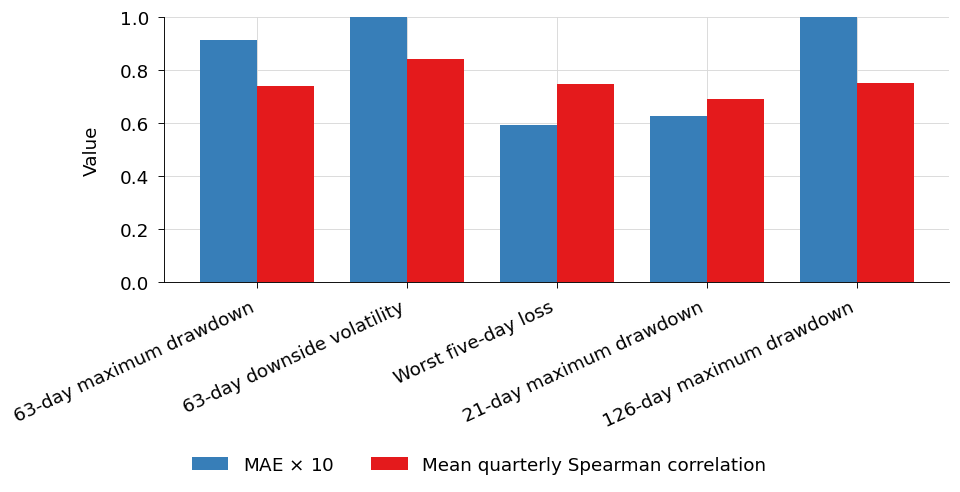

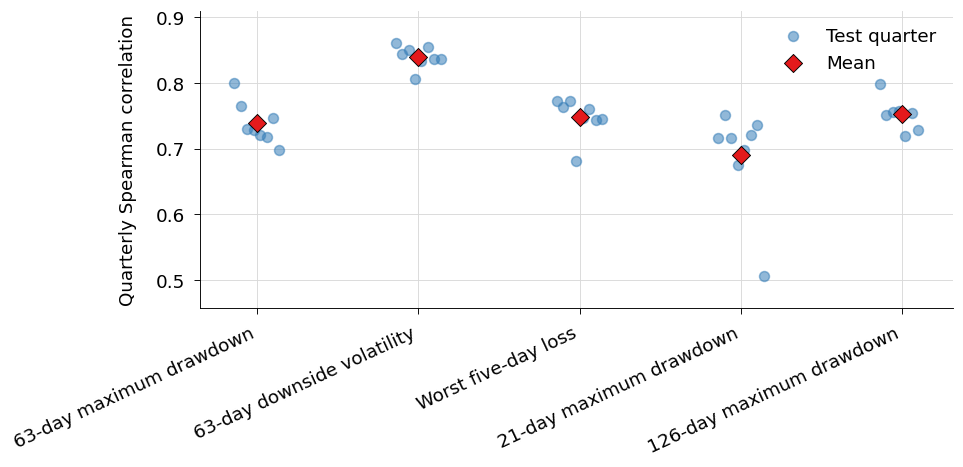

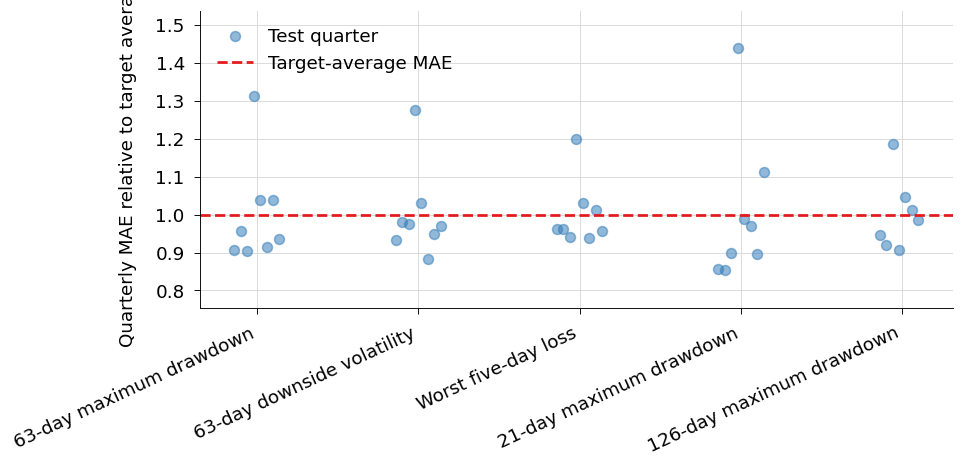

In [5]:
plot_performance = robustness_performance.copy()
plot_performance['label'] = plot_performance['target'].map(target_labels)
target_positions = np.arange(len(plot_performance))
bar_width = 0.38
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.bar(
    target_positions - bar_width / 2, 10 * plot_performance['mae'],
    width=bar_width,
    color=COLOR_PALETTE[0], label='MAE $\\times$ 10',
)
axis.bar(
    target_positions + bar_width / 2,
    plot_performance['mean_quarterly_spearman'], width=bar_width,
    color=COLOR_PALETTE[1], label='Mean quarterly Spearman correlation',
)
axis.set_ylabel('Value')
axis.set_ylim(0, 1)
axis.set_xticks(target_positions)
axis.set_xticklabels(plot_performance['label'], rotation=25, ha='right')
figure.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
)
apply_matplotlib_layout(figure)
figure.subplots_adjust(bottom=0.40)
figure.savefig(paths.figures / '04_10_xgboost_robustness_mae_spearman.pdf')
plt.show()

quarterly_rank = (
    robustness_predictions.groupby(['target', 'report_period'])
    .apply(
        lambda group: group['target_value'].corr(
            group['prediction'], method='spearman'
        ),
        include_groups=False,
    )
    .rename('spearman')
    .reset_index()
)
quarterly_rank.to_csv(
    modeling_tables / 'selected_xgboost_robustness_quarterly_spearman.csv',
    index=False,
)

target_order = list(target_labels)
quarter_order = sorted(quarterly_rank['report_period'].unique())
quarter_offsets = dict(zip(
    quarter_order, np.linspace(-0.14, 0.14, len(quarter_order))
))
means = []
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
for position, target in enumerate(target_order):
    rows = quarterly_rank.loc[quarterly_rank['target'].eq(target)].copy()
    offsets = rows['report_period'].map(quarter_offsets).to_numpy()
    axis.scatter(
        position + offsets, rows['spearman'],
        color=COLOR_PALETTE[0], alpha=0.55, s=42,
        label='Test quarter' if position == 0 else None,
    )
    means.append(rows['spearman'].mean())
axis.scatter(
    np.arange(len(target_order)), means, marker='D', s=70,
    color=COLOR_PALETTE[1], edgecolor='black', linewidth=0.6,
    label='Mean', zorder=3,
)
axis.set_xticks(np.arange(len(target_order)))
axis.set_xticklabels(
    [target_labels[target] for target in target_order],
    rotation=25, ha='right',
)
axis.set_ylabel('Quarterly Spearman correlation')
axis.set_ylim(
    max(0, quarterly_rank['spearman'].min() - 0.05),
    min(1, quarterly_rank['spearman'].max() + 0.05),
)
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / '04_10_xgboost_robustness_quarterly_spearman.pdf'
)
plt.show()

quarterly_mae = (
    robustness_predictions.assign(
        absolute_error=lambda frame: (
            frame['target_value'] - frame['prediction']
        ).abs()
    )
    .groupby(['target', 'report_period'], as_index=False)
    .agg(mae=('absolute_error', 'mean'))
)
target_mae = robustness_performance.set_index('target')['mae']
quarterly_mae['relative_mae'] = (
    quarterly_mae['mae'] / quarterly_mae['target'].map(target_mae)
)
quarterly_mae.to_csv(
    modeling_tables / 'selected_xgboost_robustness_quarterly_mae.csv',
    index=False,
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
for position, target in enumerate(target_order):
    rows = quarterly_mae.loc[quarterly_mae['target'].eq(target)].copy()
    offsets = rows['report_period'].map(quarter_offsets).to_numpy()
    axis.scatter(
        position + offsets, rows['relative_mae'],
        color=COLOR_PALETTE[0], alpha=0.55, s=42,
        label='Test quarter' if position == 0 else None,
    )
axis.axhline(
    1, color=COLOR_PALETTE[1], linestyle='--',
    label='Target-average MAE',
)
axis.set_xticks(np.arange(len(target_order)))
axis.set_xticklabels(
    [target_labels[target] for target in target_order],
    rotation=25, ha='right',
)
axis.set_ylabel('Quarterly MAE relative to target average')
axis.set_ylim(
    max(0, quarterly_mae['relative_mae'].min() - 0.10),
    quarterly_mae['relative_mae'].max() + 0.10,
)
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / '04_10_xgboost_robustness_quarterly_relative_mae.pdf'
)
plt.show()

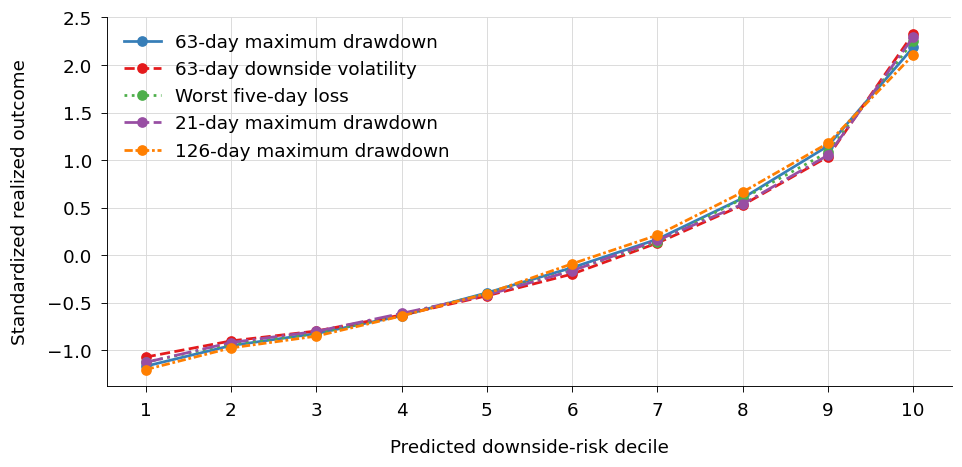

In [6]:
mean_deciles = robustness_deciles.groupby(['target', 'decile'], as_index=False).agg(
    mean_actual=('mean_actual', 'mean')
)
mean_deciles['standardized_outcome'] = mean_deciles.groupby('target')['mean_actual'].transform(
    lambda values: (values - values.mean()) / values.std(ddof=0)
)
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
for index, target in enumerate(target_labels):
    rows = mean_deciles.loc[mean_deciles['target'].eq(target)]
    axis.plot(rows['decile'], rows['standardized_outcome'], marker='o',
              color=COLOR_PALETTE[index % len(COLOR_PALETTE)],
              linestyle=linestyles[index],
              label=target_labels[target])
axis.set_xlabel('Predicted downside-risk decile')
axis.set_ylabel('Standardized realized outcome')
axis.xaxis.set_major_locator(MaxNLocator(integer=True))
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_10_xgboost_robustness_decile_profiles.pdf')
plt.show()

## Feature importance across robustness targets

The heatmap compares normalized mean absolute SHAP importance across the primary and alternative-target models. Each column sums to one, making feature use comparable despite differences in target scale.

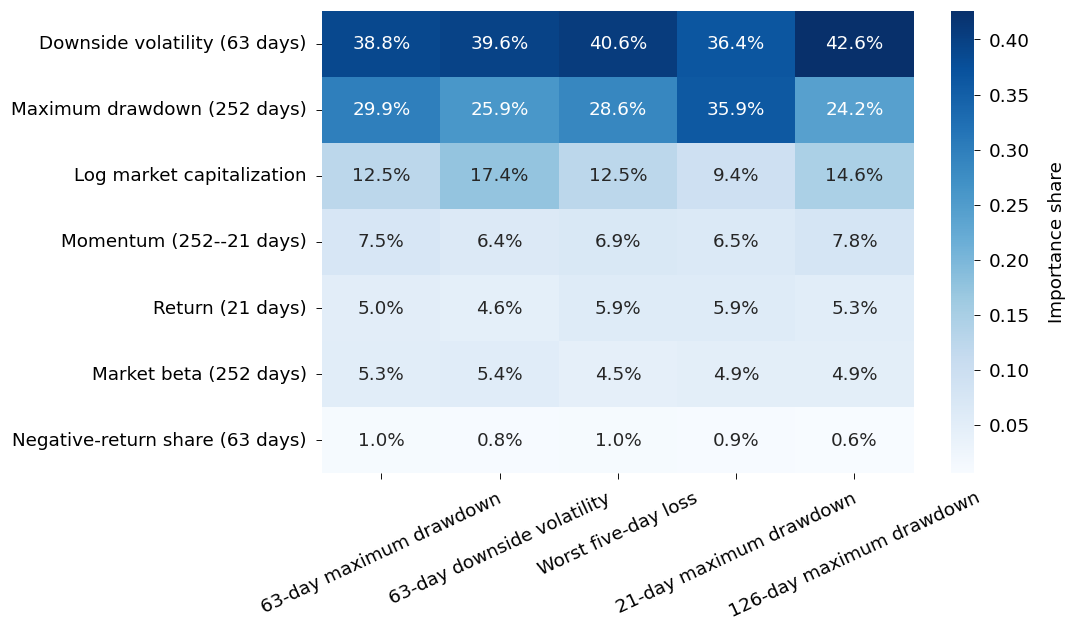

In [7]:
market_features = feature_names('market')
primary_feature_sample = pd.read_parquet(
    paths.processed / 'modeling' / 'modeling_sample.parquet',
    columns=['report_period', 'sample_split', *market_features],
).loc[lambda frame: frame['sample_split'].eq('test')]
importance_rows = []
for target_name in target_labels:
    if target_name == 'future_max_drawdown_63d':
        bundle = joblib.load(paths.models / 'final_selected_xgboost_market.joblib')
        target_sample = primary_feature_sample
    else:
        bundle = joblib.load(
            paths.models / f'robustness_xgboost_{target_name}.joblib'
        )
        target_sample = samples[target_name].loc[
            samples[target_name]['sample_split'].eq('test')
        ]
    interpretation_sample = (
        target_sample.groupby('report_period', group_keys=False, sort=True)
        .sample(n=500, random_state=project.seed)
    )
    transformed = transform_features(
        interpretation_sample, bundle['preprocessing']
    )
    explanation = shap.TreeExplainer(bundle['model'])(transformed)
    mean_absolute_shap = np.abs(explanation.values).mean(axis=0)
    importance_share = mean_absolute_shap / mean_absolute_shap.sum()
    for feature, value in zip(market_features, importance_share):
        importance_rows.append({
            'target': target_name, 'feature': feature,
            'importance_share': value,
        })

robustness_importance = pd.DataFrame(importance_rows)
robustness_importance.to_csv(
    modeling_tables / 'selected_xgboost_robustness_shap_importance.csv',
    index=False,
)
heatmap = robustness_importance.pivot(
    index='feature', columns='target', values='importance_share'
)
feature_order = heatmap.mean(axis=1).sort_values(ascending=False).index
heatmap = heatmap.loc[feature_order, list(target_labels)]
heatmap.index = [feature_labels[feature] for feature in heatmap.index]
heatmap.columns = [target_labels[target] for target in heatmap.columns]
figure, axis = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap, cmap='Blues', annot=True, fmt='.1%',
    annot_kws={'fontsize': 12},
    cbar_kws={'label': 'Importance share'}, ax=axis,
)
axis.set_ylabel('')
axis.tick_params(axis='x', rotation=25)
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / '04_10_xgboost_robustness_feature_importance_heatmap.pdf'
)
plt.show()